# Nonlinear time-dependent PDEs in FEniCSx

We can consider the **time-dependent heat equation** with a forcing term $f(u)$ that is **nonlinear** in the unknown $u$. The equations read as follows:

$$
\frac{\partial u}{\partial t} - u_{xx} = f(u)  \qquad \text{ for } x \in \Omega \text{ and for } t \in [0, T], \\
u = g  \qquad \text{ for } x \in \partial \Omega \text{ and } t \in [0, T], \\
u = u^0 \qquad \text{ for } x \in \Omega \text{ and } t = 0.
$$


$\Omega$ denotes the spatial domain and $\partial \Omega$ the domain boundary. For example for $\Omega = [-L, L]$, the boundary $\partial \Omega$ consists of the two points $-L$ and $L$. We start the simulation at time $t=0$ until the final time $T$.

The solution $u = u(x, t)$, the right-hand side $f = f (u(x, t))$ can be any nonlinear function of $u$, and the boundary value $g = g(x, t)$ may vary in space $(x)$ and time (t). The initial value $u_0$ is a function of space only.


# Newton's method can be used to linearize and solve the equation

At each time step we have the semi-discretized equation to solve:

$$F(x) = u^n − \Delta t u^n_{xx} - u^{n-1} - \Delta t f^n = 0,$$
for $n=1,\dots, N.$

Since $f(u)$ is a nonlinear expression of $u$ we need to define a method to linearize the equation. For example, we can use **Newton's method**.

In [ ]:
from IPython.display import HTML

HTML(
    '<a title="By Ralf Pfeifer (de:Image:NewtonIteration Ani.gif) [GFDL (http://www.gnu.org/copyleft/fdl.html) or CC-BY-SA-3.0 (http://creativecommons.org/licenses/by-sa/3.0/)], via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File%3ANewtonIteration_Ani.gif"><img width="512" alt="NewtonIteration Ani" src="https://upload.wikimedia.org/wikipedia/commons/e/e0/NewtonIteration_Ani.gif"/></a>'
)

## Some implementation tips

If you use FEniCSx you do not need to implement a Newton's scheme since it is already implemented!

Anyway, there are a few differences compared to the linear case in the syntax.

In [ ]:
from dolfinx import fem, mesh
from dolfinx.fem.petsc import NonlinearProblem
from ufl import TestFunction, inner, dx, grad
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

# Setup mesh and function space
domain = mesh.create_unit_interval(MPI.COMM_WORLD, 100)
V = fem.functionspace(domain, ("CG", 1))

u = fem.Function(V)  # current solution
u0 = fem.Function(V)  # previous solution
v = TestFunction(V)


# Boundary conditions
def left_boundary(x):
    return np.isclose(x[0], 0.0)


def right_boundary(x):
    return np.isclose(x[0], 1.0)


fdim = domain.topology.dim - 1
left_facets = mesh.locate_entities_boundary(domain, fdim, left_boundary)
right_facets = mesh.locate_entities_boundary(domain, fdim, right_boundary)

left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
right_dofs = fem.locate_dofs_topological(V, fdim, right_facets)

# Apply Dirichlet conditions (0 on left end and 1 on right end)
bc_left = fem.dirichletbc(0.0, left_dofs, V)
bc_right = fem.dirichletbc(1.0, right_dofs, V)
bcs = [bc_left, bc_right]

# Parameters and nonlinear form
dt_val = 0.02
dt = fem.Constant(domain, dt_val)
D = fem.Constant(domain, 0.1)

# Residual equation F = a - L = 0
F = (
    (u / dt) * v * dx
    + D * inner(grad(u), grad(v)) * dx
    - (u0 / dt) * v * dx
    - u * u * v * dx
)

# Nonlinear solver setup
problem = NonlinearProblem(F, u, bcs=bcs, petsc_options_prefix="nonlinear_basic_")

t = 0.0
T = 0.25

# Extract coordinates for Matplotlib
x_coords = V.tabulate_dof_coordinates()[:, 0]

plt.figure(figsize=(8, 6))

while t <= T - dt_val:
    t += dt_val

    # Solve the nonlinear system F == 0
    problem.solve()

    # Prepare for next timestep
    u0.x.array[:] = u.x.array

    # Plot
    plt.plot(x_coords, u.x.array, label=f"t={t:.2f}")

# Finalize Plot
plt.xlabel("x")
plt.ylabel("u")
plt.title("Time-Dependent Heat Equation")
plt.legend()
plt.show()

In this case, we do not define a `TrialFunction` but only a `Function`. Both the left and the right hand side change at every time step. Therefore, it is not possible to assemble the matrix before the time loop unlike the linear case. In addition, the form needs to be written such that everything is on the left-hand side (F==0).

## FEniCSx challenge 
Solve the cubic, bistable cable equation on an interval $\Omega=[-L, L]$ in FEniCSx 
$$
\frac{\partial u}{\partial t} = \sigma u_{xx} + f(u) \quad \text{ for } -L < x < L, \\
u_x = 0 \quad \text{ for } x = -L \text{ and } x = L,
$$
with 
* $f(u) = Au(1-u)(u-\alpha)$,
* $\alpha = 0.1$,
* $A = 1.0$.
* $\sigma = 1.0$,
* $L = 100$.

Implement an implicit Euler time-stepping scheme and solve the problem from $t=0$ to $T=250$ with a time step of $dt=2.5$. Use as initial condition

$$
    \frac{1}{2} \left( \exp(-x^2) - \exp(-(x-L)^2) \right)
$$

Note that the initial conditions look like two bumps - one positive at $x=0$, one negative at $x=L$. What do you think will happen to them as $t$ increases?

## FEniCSx challenge solution

See below. Note that I have used $\sigma=0.1$ instead of $\sigma=1.0$. It is interesting to vary this and see how it affects whether the initial bump causes a propagating potential or not. Varying $\alpha$ is also interesting - what effect do you think this will have?

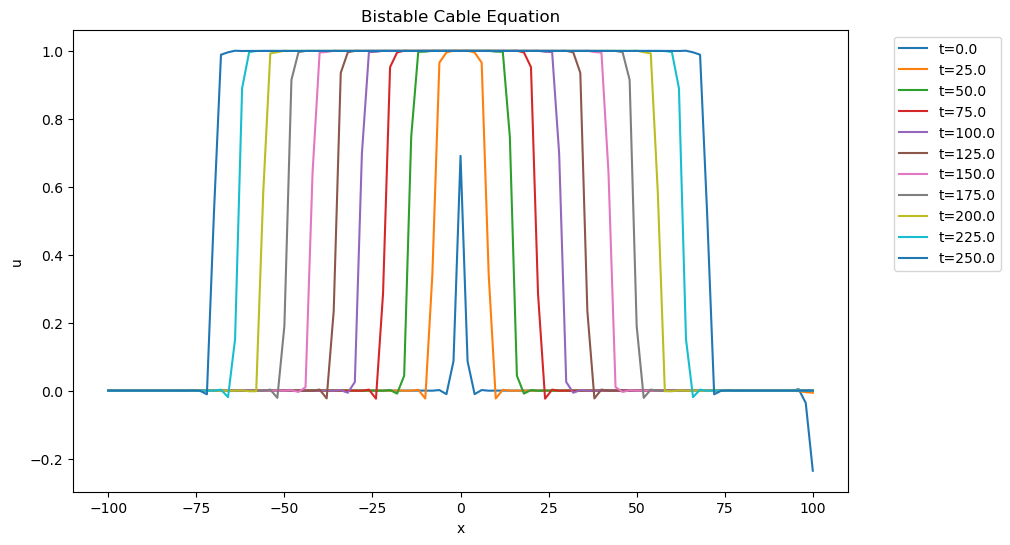

In [2]:
from dolfinx import fem, mesh
from dolfinx.fem.petsc import NonlinearProblem
from ufl import TestFunction, dx, inner, grad
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

# Setup mesh and function space
domain = mesh.create_interval(MPI.COMM_WORLD, 100, [-100.0, 100.0])
V = fem.functionspace(domain, ("CG", 1))

# Initialize functions
u = fem.Function(V)
u0 = fem.Function(V)
v = TestFunction(V)

# Parameters
t = 0.0
T = 250.0
dt_val = 2.5
L_val = 100.0

dt = fem.Constant(domain, dt_val)
A = fem.Constant(domain, 1.0)
alpha = fem.Constant(domain, 0.1)
sigma = fem.Constant(domain, 0.1)


# Initial condition
def initial_condition(x):
    return 0.5 * np.exp(-x[0] ** 2) - 0.5 * np.exp(-((x[0] - L_val) ** 2))


u0.interpolate(initial_condition)

# Provide an initial guess for the Newton solver (using the initial condition)
u.x.array[:] = u0.x.array


# Nonlinear reaction term and variational formulation
def f(u_func):
    return A * u_func * (1.0 - u_func) * (u_func - alpha)


# Residual F = a - L = 0
F = (
    (u / dt) * v * dx
    + sigma * inner(grad(u), grad(v)) * dx
    - (u0 / dt) * v * dx
    - f(u) * v * dx
)

# Nonlinear solver setup
problem = NonlinearProblem(F, u, petsc_options_prefix="bistable_")

# Time loop setup
solutions = []
time_steps = np.arange(0, T + dt_val, dt_val)

# Extract coordinates for plotting
x_coords = V.tabulate_dof_coordinates()[:, 0]

plt.figure(figsize=(10, 6))

for i, t in enumerate(time_steps):

    # Solve the nonlinear system
    problem.solve()

    # Update previous solution
    u0.x.array[:] = u.x.array

    # Store the time and a copy of the raw data array
    solutions.append((t, u0.x.array.copy()))

    # Plot every 10 timesteps
    if i % 10 == 0:
        plt.plot(x_coords, u.x.array, label=f"t={t:.1f}")

# Finalize plot
plt.xlabel("x")
plt.ylabel("u")
plt.title("Bistable Cable Equation")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()